In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
columns = ['Crime_Rate',
    'Zoned_Land_Proportion',
    'Non_Retail_Business_Acres',
    'Charles_River_Boundary',
    'Nitric_Oxide_Concentration',
    'Average_Rooms',
    'Proportion_Older_Homes',
    'Distance_To_Work_Centers',
    'Highway_Accessibility',
    'Property_Tax_Rate',
    'Pupil_Teacher_Ratio',
    'Black_Population_Prop',
    'Lower_Status_Pop_Percent',
    'Median_Home_Value']



df = pd.read_csv("dataset/house_Prediction_Data_Set.csv", sep='\s+', header=None, names=columns)
df.head()

,Crime_Rate,Zoned_Land_Proportion,Non_Retail_Business_Acres,Charles_River_Boundary,Nitric_Oxide_Concentration,Average_Rooms,Proportion_Older_Homes,Distance_To_Work_Centers,Highway_Accessibility,Property_Tax_Rate,Pupil_Teacher_Ratio,Black_Population_Prop,Lower_Status_Pop_Percent,Median_Home_Value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.shape

(506, 14)

In [4]:
df.describe()

,Crime_Rate,Zoned_Land_Proportion,Non_Retail_Business_Acres,Charles_River_Boundary,Nitric_Oxide_Concentration,Average_Rooms,Proportion_Older_Homes,Distance_To_Work_Centers,Highway_Accessibility,Property_Tax_Rate,Pupil_Teacher_Ratio,Black_Population_Prop,Lower_Status_Pop_Percent,Median_Home_Value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
df.columns[df.isna().any()]

Index([], dtype='str')

In [6]:
df.isna().sum()

Crime_Rate                    0
Zoned_Land_Proportion         0
Non_Retail_Business_Acres     0
Charles_River_Boundary        0
Nitric_Oxide_Concentration    0
Average_Rooms                 0
Proportion_Older_Homes        0
Distance_To_Work_Centers      0
Highway_Accessibility         0
Property_Tax_Rate             0
Pupil_Teacher_Ratio           0
Black_Population_Prop         0
Lower_Status_Pop_Percent      0
Median_Home_Value             0
dtype: int64

## Checking missing values

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print(missing_summary.sort_values("missing_count", ascending=False))

Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


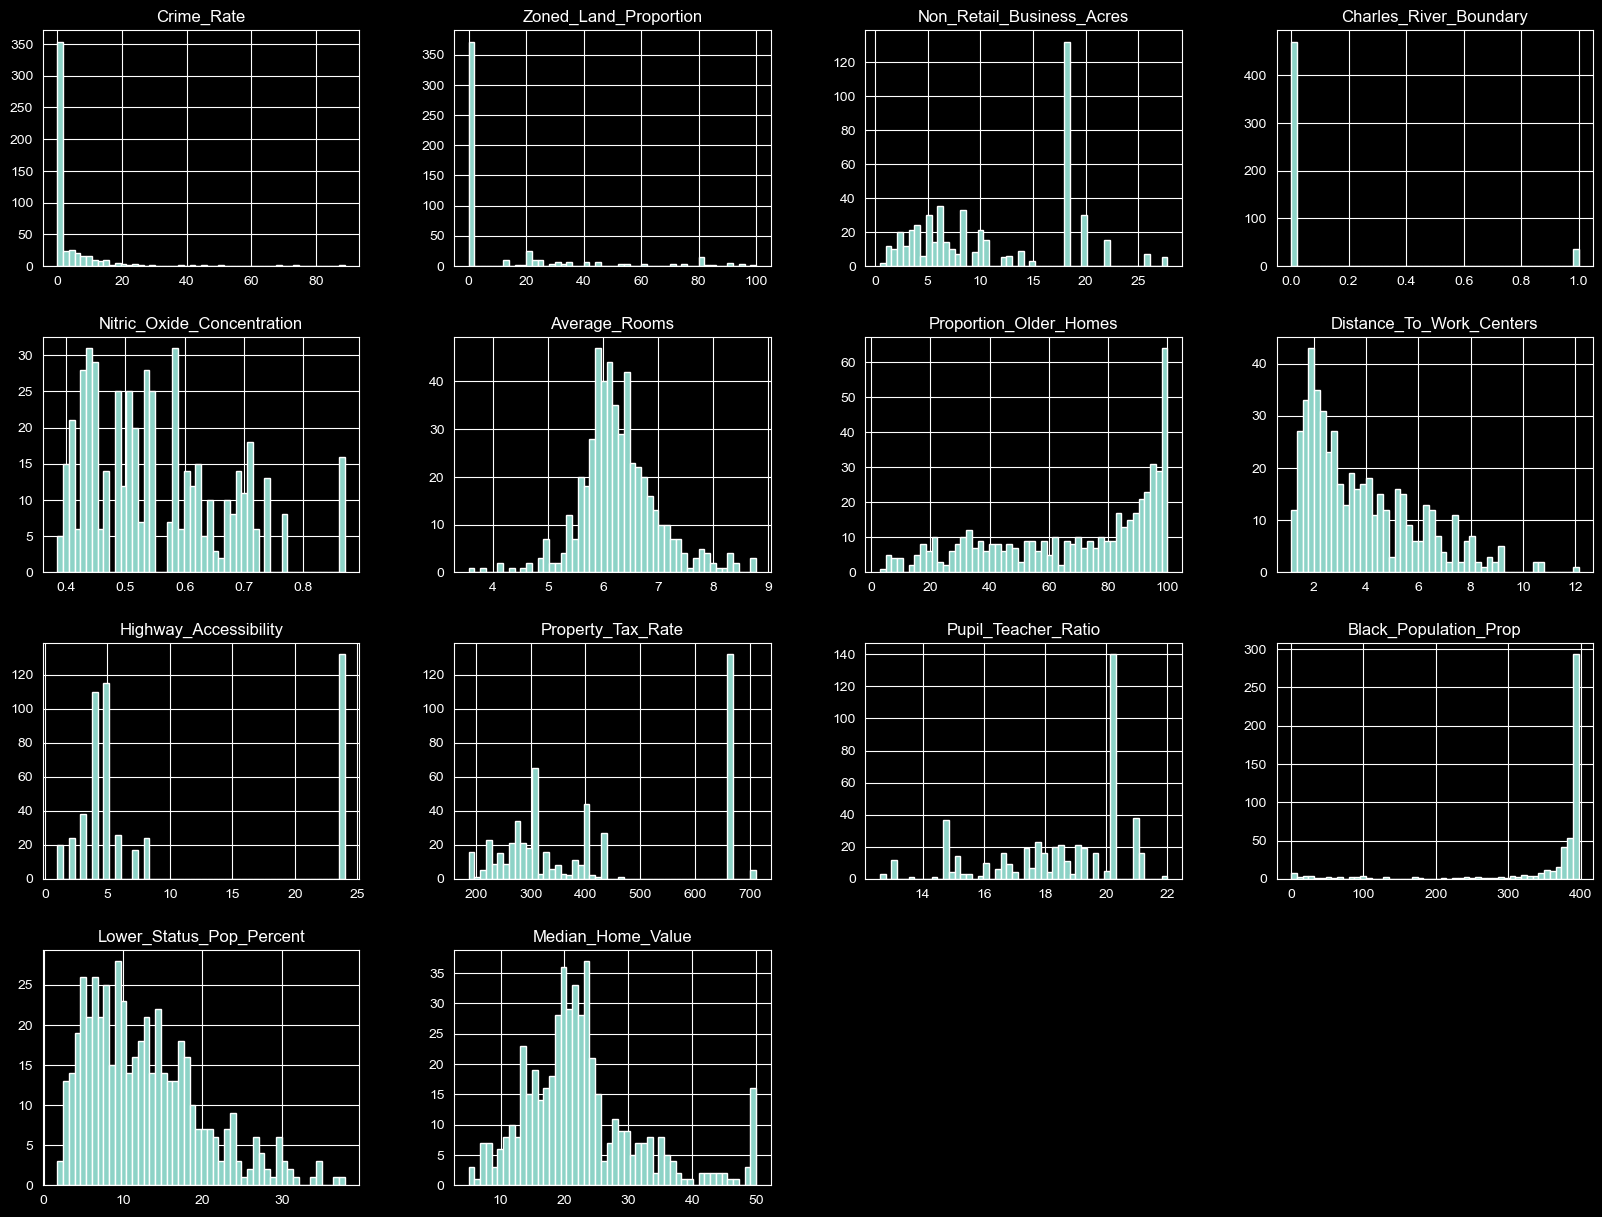

In [8]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X = df.drop('Median_Home_Value', axis=1)
y = df['Median_Home_Value']

X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=0.2)

In [10]:
X_train.head()

,Crime_Rate,Zoned_Land_Proportion,Non_Retail_Business_Acres,Charles_River_Boundary,Nitric_Oxide_Concentration,Average_Rooms,Proportion_Older_Homes,Distance_To_Work_Centers,Highway_Accessibility,Property_Tax_Rate,Pupil_Teacher_Ratio,Black_Population_Prop,Lower_Status_Pop_Percent
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666.0,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307.0,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304.0,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666.0,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307.0,21.0,390.95,11.28


In [11]:
y_train.head()

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
Name: Median_Home_Value, dtype: float64

## Correlation of data

In [12]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix['Median_Home_Value'].sort_values(ascending=False)

Median_Home_Value             1.000000
Average_Rooms                 0.695360
Zoned_Land_Proportion         0.360445
Black_Population_Prop         0.333461
Distance_To_Work_Centers      0.249929
Charles_River_Boundary        0.175260
Proportion_Older_Homes       -0.376955
Highway_Accessibility        -0.381626
Crime_Rate                   -0.388305
Nitric_Oxide_Concentration   -0.427321
Property_Tax_Rate            -0.468536
Non_Retail_Business_Acres    -0.483725
Pupil_Teacher_Ratio          -0.507787
Lower_Status_Pop_Percent     -0.737663
Name: Median_Home_Value, dtype: float64

<Axes: >

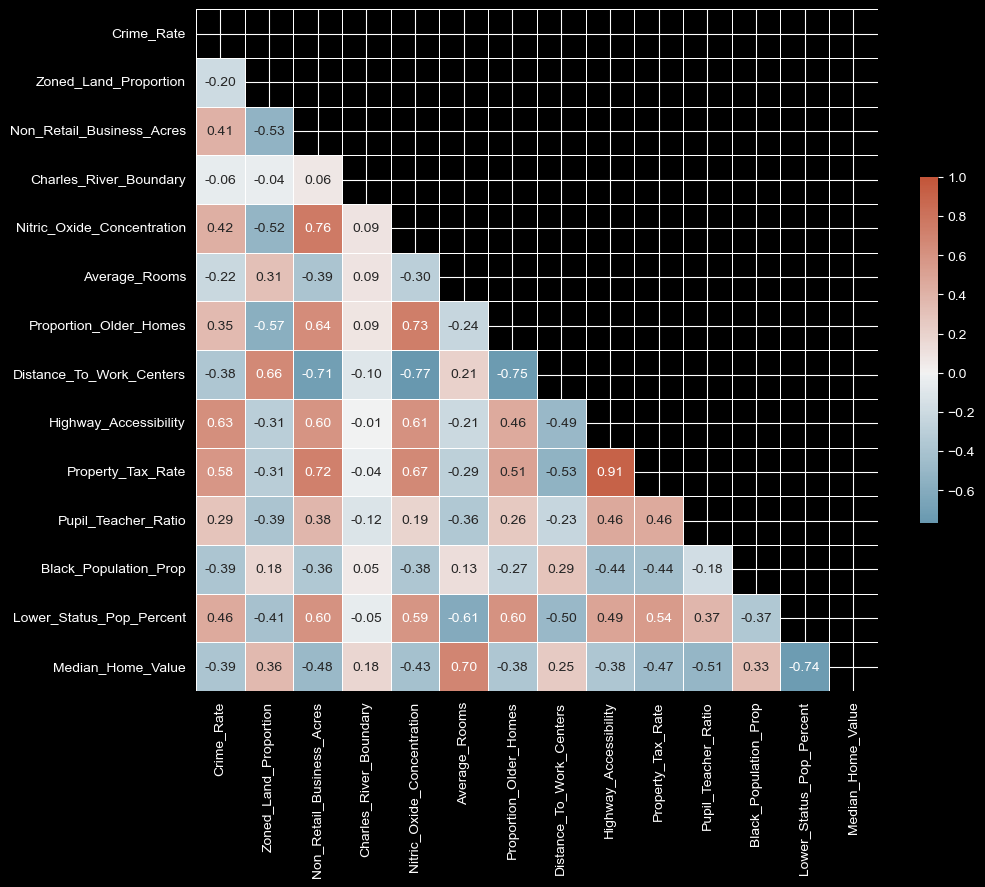

In [17]:

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f")

## Training and evaluating Linear Regression model

In [18]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
Actual_data = X_train.iloc[:5]
actual_labels = y_train.iloc[:5]
predictions = lin_reg.predict(Actual_data)
print('Prediction\t', predictions)
print('Labels\t', list(actual_labels))

Prediction	 [10.96952405 19.41196567 23.06419602 12.1470648  18.3738116 ]
Labels	 [12.0, 19.9, 19.4, 13.4, 18.2]


## RMSE Calculation of the linear regression Model using mean_squared_function

In [21]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(X_train)
lin_mse = mean_squared_error(y_train, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(4.6520331848801675)

## Model Coefficient

In [19]:
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lin_reg.coef_
})


print(coefficients_df.sort_values(by='Coefficient', ascending=False))

                       Feature  Coefficient
5                Average_Rooms     4.438835
3       Charles_River_Boundary     2.784438
8        Highway_Accessibility     0.262430
2    Non_Retail_Business_Acres     0.040381
1        Zoned_Land_Proportion     0.030110
11       Black_Population_Prop     0.012351
6       Proportion_Older_Homes    -0.006296
9            Property_Tax_Rate    -0.010647
0                   Crime_Rate    -0.113056
12    Lower_Status_Pop_Percent    -0.508571
10         Pupil_Teacher_Ratio    -0.915456
7     Distance_To_Work_Centers    -1.447865
4   Nitric_Oxide_Concentration   -17.202633
